## Iris Project

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [9]:
# Laod the Data sets
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB


In [18]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,150.0,NaN,NaN,NaN,75.5,43.445368,1.0,38.25,75.5,112.75,150.0
SepalLengthCm,150.0,NaN,NaN,NaN,5.843333,0.828066,4.3,5.1,5.8,6.4,7.9
SepalWidthCm,150.0,NaN,NaN,NaN,3.054,0.433594,2.0,2.8,3.0,3.3,4.4
PetalLengthCm,150.0,NaN,NaN,NaN,3.758667,1.76442,1.0,1.6,4.35,5.1,6.9
PetalWidthCm,150.0,NaN,NaN,NaN,1.198667,0.763161,0.1,0.3,1.3,1.8,2.5
Species,150,3,Iris-setosa,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [22]:
# Checking null Values
df.isnull().sum().sum()

np.int64(0)

In [21]:
# Checking duplicate Values
df.duplicated().sum()

np.int64(0)

In [37]:
# Droping the ID Column Cuz its not need un this Project
df.drop(columns=['Id'], inplace=True)

In [38]:
df.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

In [23]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

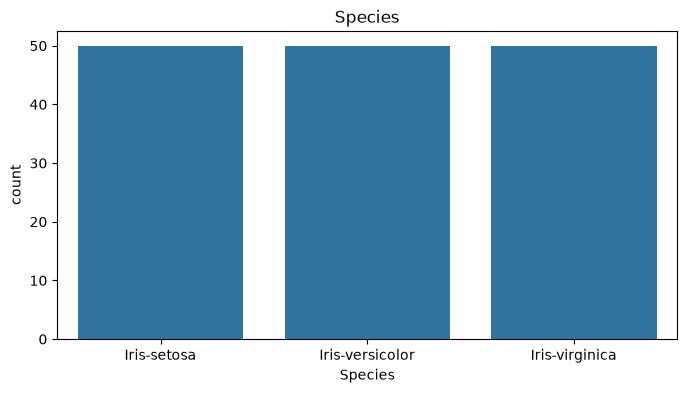

In [28]:
#cheking Ouliers in species by count plot
plt.figure(figsize=(8 ,4))
sns.countplot(x = df['Species'] ,width=0.8 , legend='auto')
plt.title('Species')
plt.xlabel("Species")
plt.show()

## EDA

In [42]:
df.columns.to_list()

['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

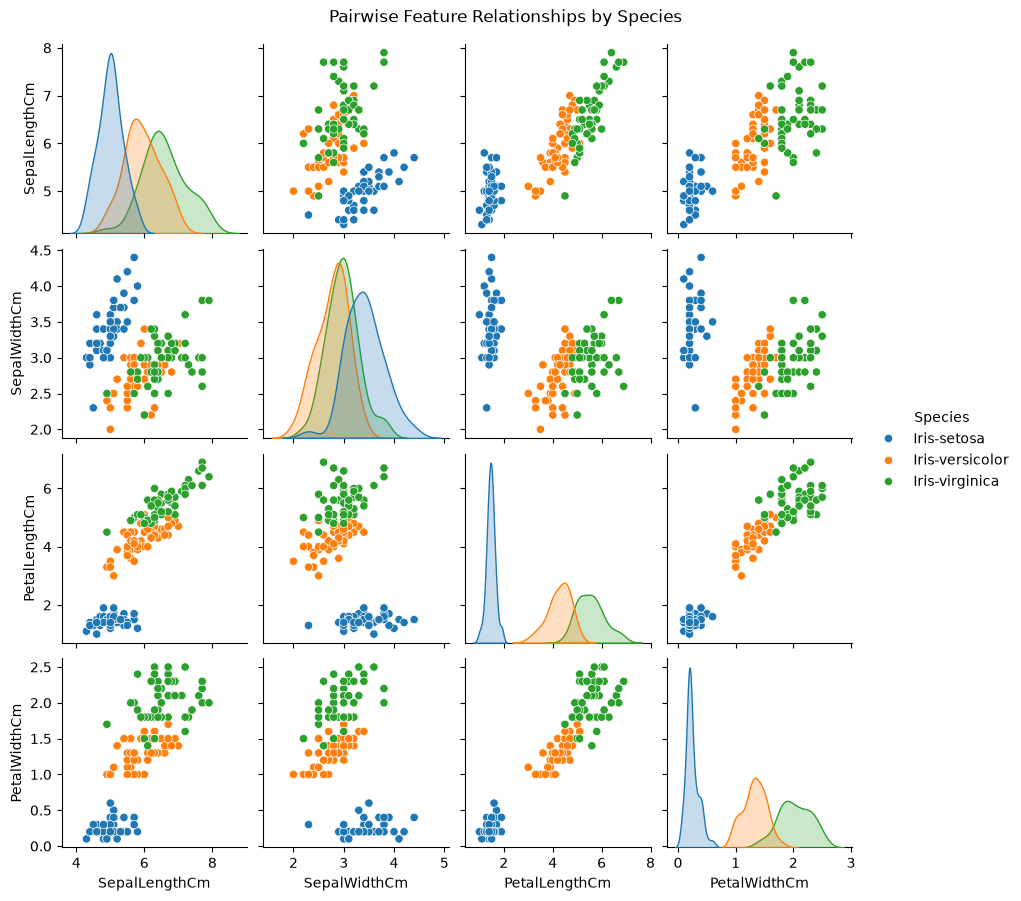

In [47]:
# pair plot againt Species
sns.pairplot(data = df , hue= 'Species' , diag_kind ="kde" , height= 2.2)
plt.suptitle('Pairwise Feature Relationships by Species' , y = 1.02)
# plt.tight_layout()
plt.show()

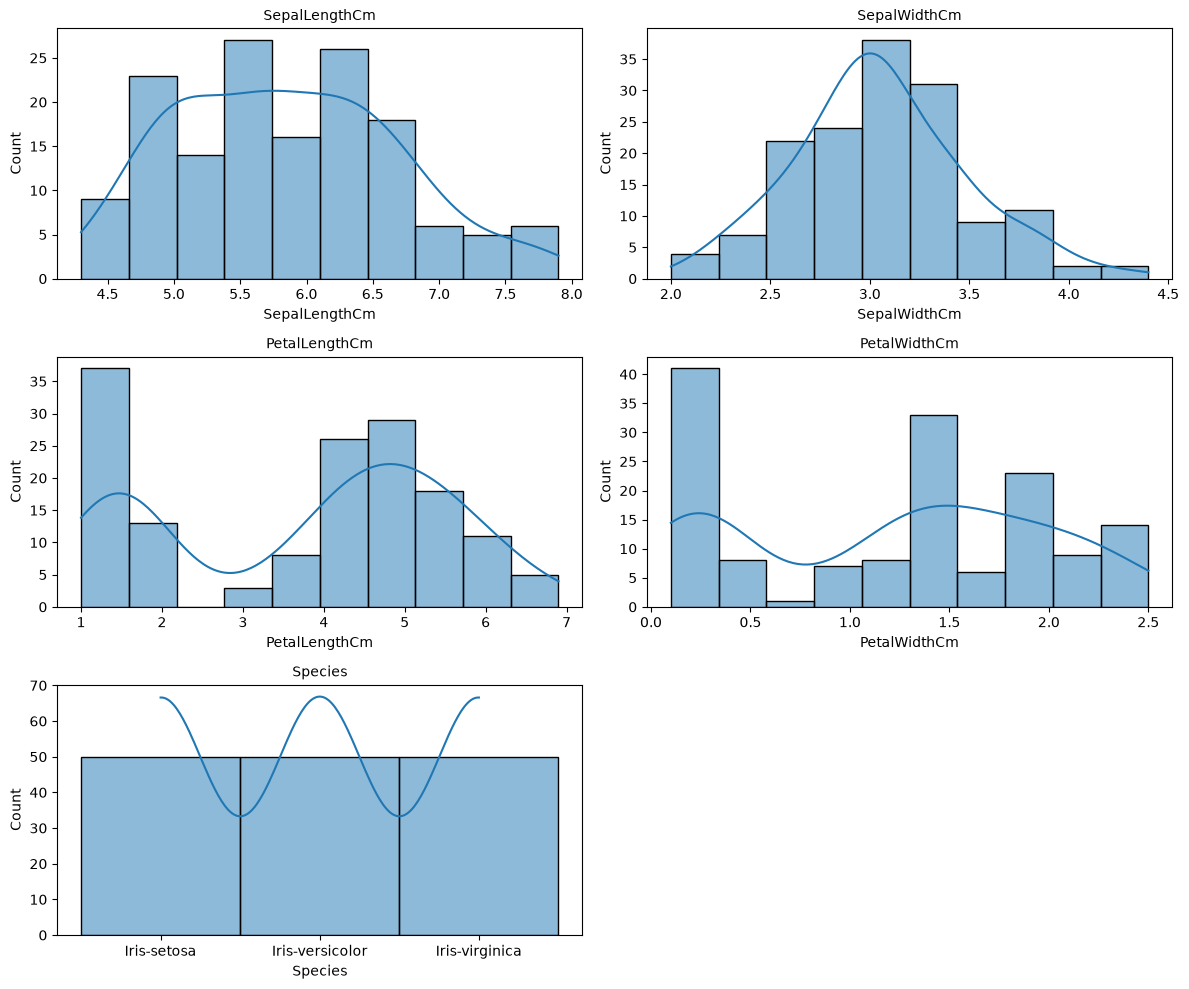

In [55]:
#hist plot 
plt.figure(figsize=(12 , 10))
def plotting(var ,col):
    plt.subplot(3 , 2 , col);
    sns.histplot(data = df ,  x = var , kde = True , bins= 10 , palette='dark' , legend= 'auto' ,)
    plt.title(var , fontsize = 10)

plotting('SepalLengthCm' , 1)
plotting('SepalWidthCm' , 2)
plotting('PetalLengthCm' , 3)
plotting('PetalWidthCm' , 4)
plotting('Species' , 5)

plt.tight_layout()
plt.show()

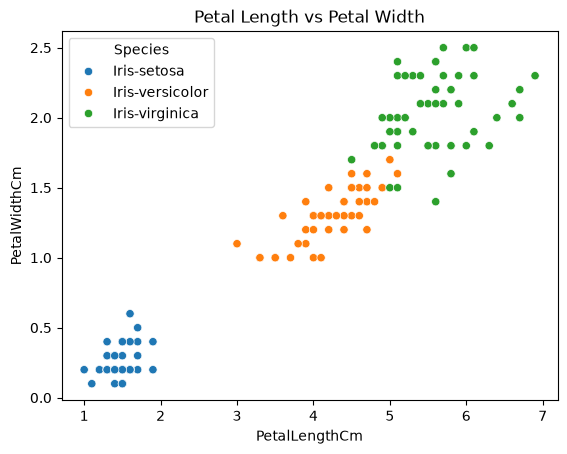

In [56]:
sns.scatterplot(
    data=df,
    x='PetalLengthCm',
    y='PetalWidthCm',
    hue='Species'
)
plt.title('Petal Length vs Petal Width')
plt.show()

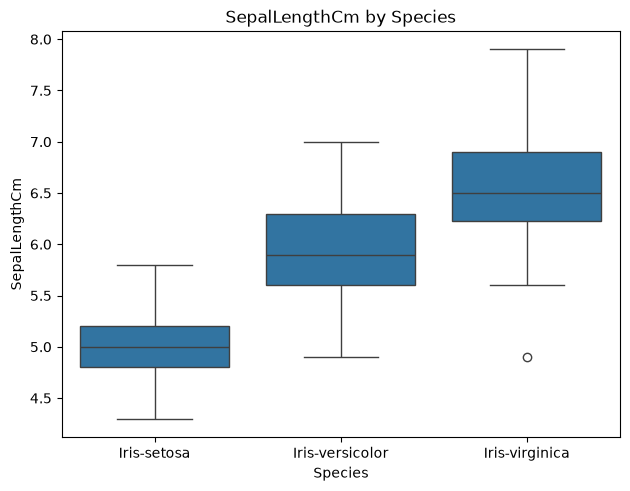

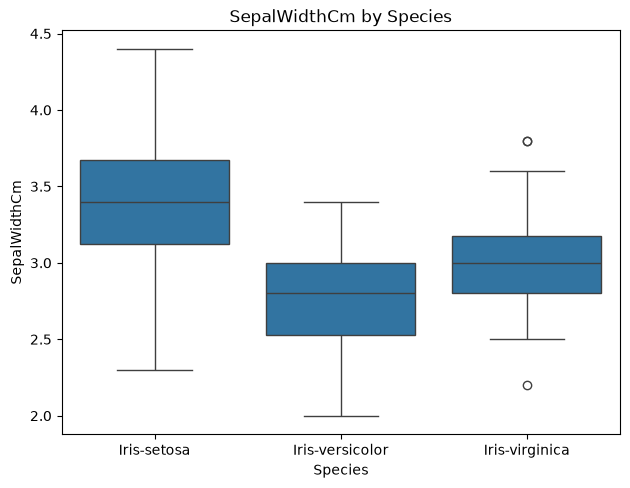

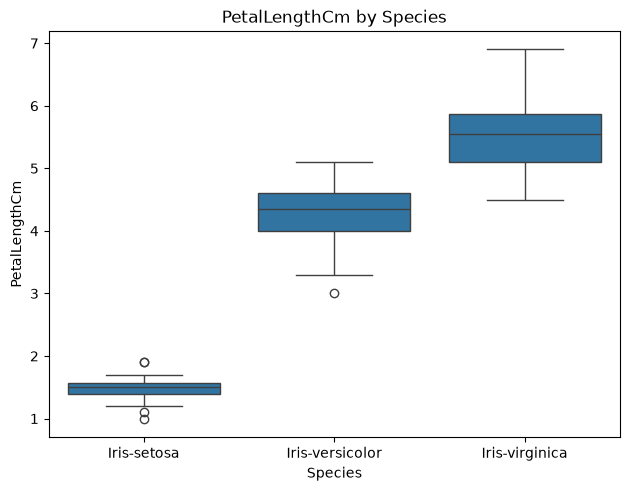

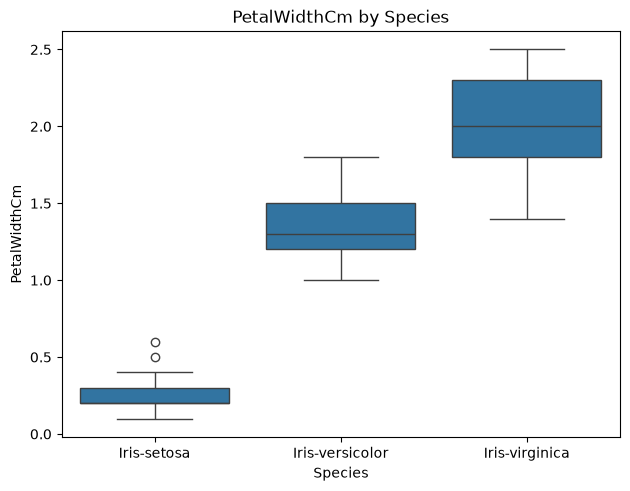

In [63]:
# Box Plot by species analysis the Outliers
features = [
    'SepalLengthCm',
    'SepalWidthCm',
    'PetalLengthCm',
    'PetalWidthCm'
]

for feature in features:
    sns.boxplot(data=df,x='Species',y=feature)

    plt.tight_layout()
    plt.title(f'{feature} by Species')
    plt.show()

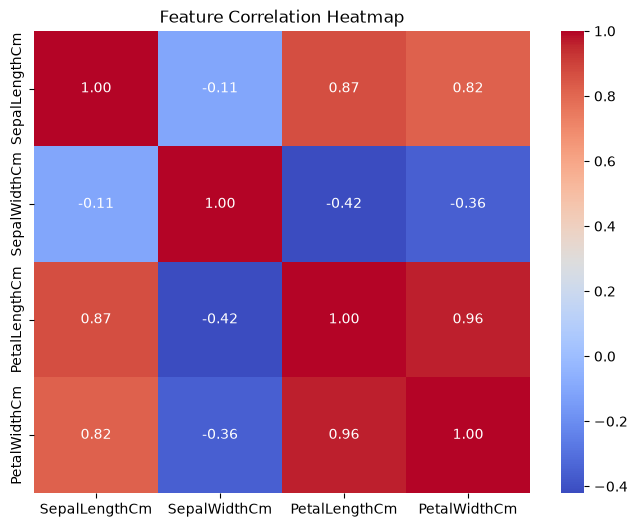

In [73]:
#heat Map 
features = [
    'SepalLengthCm',
    'SepalWidthCm',
    'PetalLengthCm',
    'PetalWidthCm'
]
corr = df[features].corr()
plt.figure(figsize=(8 ,6))

sns.heatmap(corr ,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## Feature Engineering

In [80]:
# Analysis the Outliers
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = (df[features] < lower ) | (df[features] > upper)
print(outliers.sum())

SepalLengthCm    0
SepalWidthCm     4
PetalLengthCm    0
PetalWidthCm     0
dtype: int64


In [81]:
# skweness
skweness = df[features].skew()
print(skweness)
# shewNess is better 

SepalLengthCm    0.314911
SepalWidthCm     0.334053
PetalLengthCm   -0.274464
PetalWidthCm    -0.104997
dtype: float64


In [82]:
# After i see swekness this is better the keep the outiler its not effecct my Model

## Train Test Split


In [121]:
# Grouping the coulums
numerical_col = ['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']

X = df[numerical_col]
y = df['Species']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [131]:
print("X:", X.shape)
print("y:", y.shape)
print("Classes:", lb.classes_)

X: (150, 4)
y: (150,)
Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [138]:
## Label Encoding on Species
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y_encoded = lb.fit_transform(y)

print(y_encoded)
print(lb.classes_)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [145]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y_encoded,test_size=0.2,random_state=42,shuffle=True,stratify=y_encoded)

In [146]:
#printing the value 0f train, test 
print("X_train:", x_train.shape)
print("X_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (120, 4)
X_test: (30, 4)
y_train: (120,)
y_test: (30,)


##  Preprocessing using ColumnTransformer

In [147]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('num' , StandardScaler() , numerical_col),
])

print("ColumnTransformer configured:")
preprocessor

ColumnTransformer configured:


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{fe

## Traning the Model with Diffeent - Diffrent Algorithums

In [148]:
#model with Different - Different Algorithums
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

#Evaluation
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score, confusion_matrix , classification_report
from sklearn.model_selection import cross_val_score , GridSearchCV

In [153]:
# Prediction
#Model in dict.
classifiers = {
    "Logistic Regression " : LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs'),
    "Decision Tree " : DecisionTreeClassifier(max_depth=4, min_samples_split=4, min_samples_leaf=2, criterion='gini', random_state=42),
    "Random Forest " : RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_split=4, min_samples_leaf=2, max_features='sqrt',random_state=42),
    "Support Vector " : SVC(C=1.0,  kernel='rbf', gamma='scale'),
    "XGBoost " : XGBClassifier(n_estimators=200, max_depth=3 , learning_rate=0.05 , subsample=0.9, colsample_bytree=0.9, random_state=42),
}

#Creating Pipeline for all Model
pipelines = {
    name: Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", clf),
    ])
    for name, clf in classifiers.items()
}

In [158]:
#Printing The Result
result = []
for name, pipeline in pipelines.items():
 
    pipeline.fit(x_train, y_train) #train

    y_pred = pipeline.predict(x_test) # pred

    cv_score = cross_val_score(pipeline,x_train,y_train,cv=5,scoring='accuracy')

    result.append({
        "Model": name,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro"),
        "Recall": recall_score(y_test, y_pred, average="macro"),
        "F1 Score": f1_score(y_test, y_pred, average="macro"),
        "CV Mean Accuracy": cv_score.mean(),
        "CV STD": cv_score.std()
    })


result_df = pd.DataFrame(result)
result_df = result_df.sort_values(by="CV Mean Accuracy",ascending=False).reset_index(drop=True)

# Display 
print(result_df)

                  Model  Test Accuracy  Precision    Recall  F1 Score  \
0       Support Vector        0.966667   0.969697  0.966667  0.966583   
1  Logistic Regression        0.933333   0.933333  0.933333  0.933333   
2        Random Forest        0.966667   0.969697  0.966667  0.966583   
3              XGBoost        0.900000   0.902357  0.900000  0.899749   
4        Decision Tree        0.933333   0.933333  0.933333  0.933333   

   CV Mean Accuracy    CV STD  
0          0.966667  0.031180  
1          0.958333  0.026352  
2          0.950000  0.016667  
3          0.950000  0.016667  
4          0.933333  0.020412  


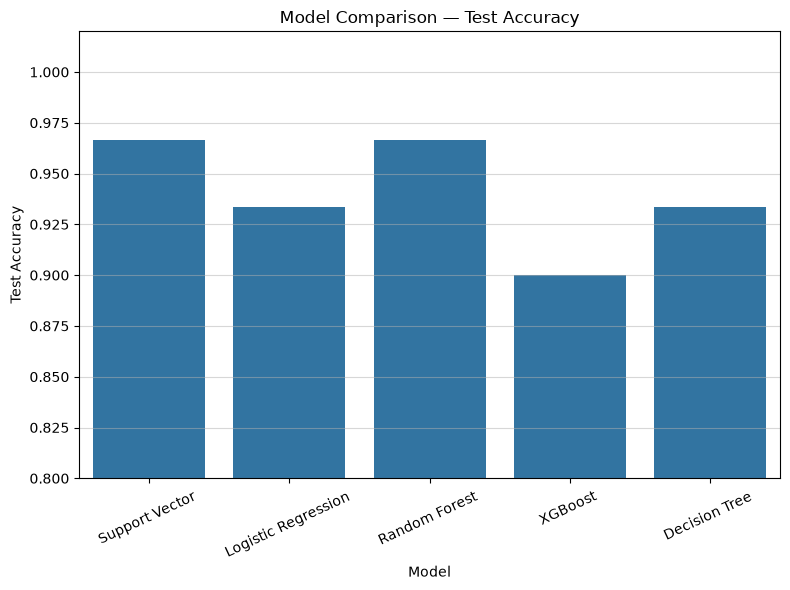

In [162]:
#To Show in Graph which Model Best
plt.figure(figsize=(8 , 6))
sns.barplot(data = result_df , x = 'Model' , y = "Test Accuracy")
plt.title("Model Comparison — Test Accuracy")
plt.xticks(rotation = 25)
plt.ylim(0.8, 1.02)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

In [168]:
#best Modela and best Prediction on Accuracy
best_model_name = result_df.iloc[0]['Model']
best_pipeline = pipelines[best_model_name]
print(f"Best - Model :  {best_model_name}")

y_pred_best = best_pipeline.predict(x_test)
print("\nClassification Report: \n")
print(classification_report(y_test , y_pred_best , target_names= lb.classes_))

Best - Model :  Support Vector 

Classification Report: 

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30




Confusion Matrix
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


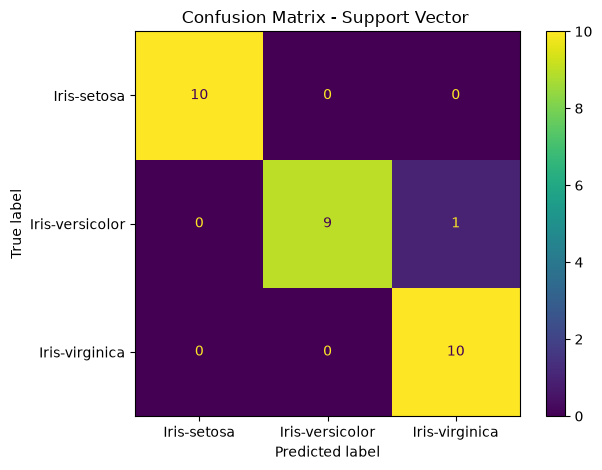

In [170]:
#Confusion Matrix
cm = confusion_matrix(y_test , y_pred_best)
print("\nConfusion Matrix")
print(cm)

#By HeatMap to visualization
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix = cm , display_labels= lb.classes_)
disp.plot()

plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

In [174]:
# Calculate permutation importance
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_pipeline,
    x_test,
    y_test,
    scoring='accuracy',
    n_repeats=10,
    random_state=42
)
# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': numerical_col,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance',ascending=False)

print(feature_importance)

         Feature  Importance
3   PetalWidthCm    0.296667
2  PetalLengthCm    0.240000
1   SepalWidthCm    0.063333
0  SepalLengthCm    0.006667


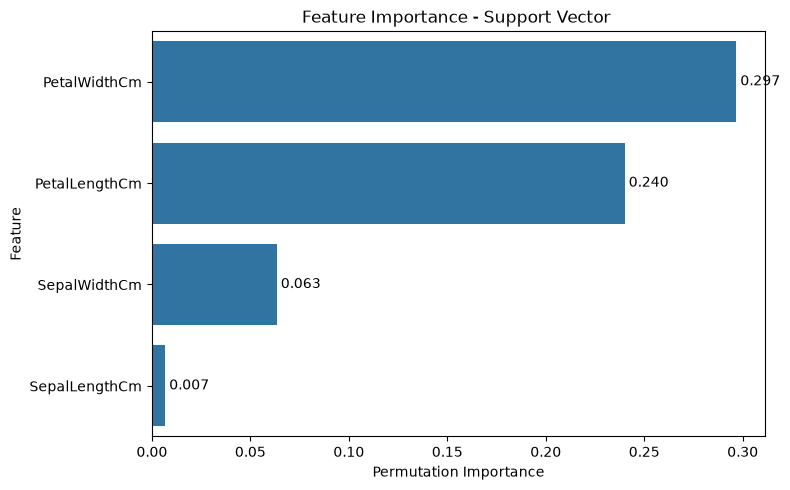

In [175]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=feature_importance,x='Importance',y='Feature')

plt.title(f'Feature Importance - {best_model_name}')
plt.xlabel('Permutation Importance')
plt.ylabel('Feature')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

## SAVE Model

In [176]:
import joblib

joblib.dump(best_pipeline , 'iris_best_model.pkl')
joblib.dump(lb , 'iris_label_encoder.pkl')

print("Model saved successfully!")
print("Label Encoder saved successfully!")

Model saved successfully!
Label Encoder saved successfully!
